DATASET LOADED SUCCESSFULLY

DATASET SHAPE
(161, 14)

COLUMN NAMES
['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']

DATA TYPES
Product_id        int64
Price             int64
Sale              int64
weight          float64
resoloution     float64
ppi               int64
cpu core          int64
cpu freq        float64
internal mem    float64
ram             float64
RearCam         float64
Front_Cam       float64
battery           int64
thickness       float64
dtype: object

MISSING VALUES
Product_id      0
Price           0
Sale            0
weight          0
resoloution     0
ppi             0
cpu core        0
cpu freq        0
internal mem    0
ram             0
RearCam         0
Front_Cam       0
battery         0
thickness       0
dtype: int64

DUPLICATE ROWS
0

STATISTICAL SUMMARY
        Product_id        Price         Sale      weight  resoloution  \
count   161.000000 

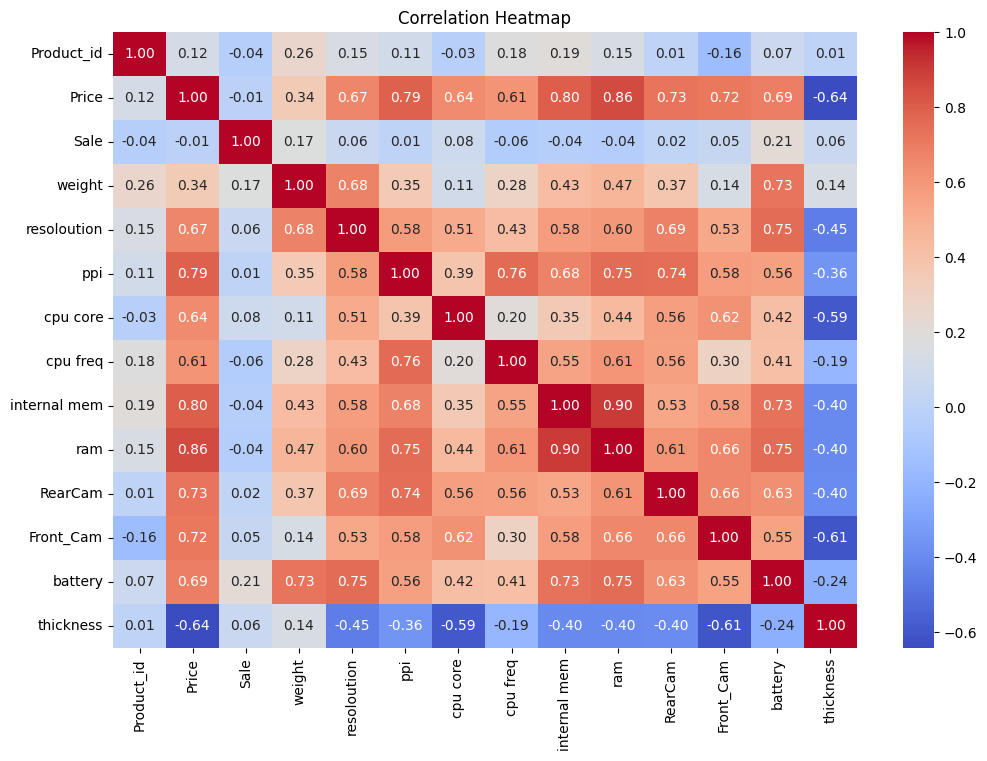


TARGET COLUMN : Price

CORRELATION WITH PRICE
Price           1.000000
ram             0.857641
internal mem    0.799546
ppi             0.792556
RearCam         0.725162
Front_Cam       0.716016
battery         0.688910
resoloution     0.665036
cpu core        0.643344
cpu freq        0.609388
weight          0.343152
Product_id      0.123573
Sale           -0.009050
thickness      -0.642115
Name: Price, dtype: float64

TOP 4 FEATURES MOST CORRELATED WITH PRICE
ram             0.857641
internal mem    0.799546
ppi             0.792556
RearCam         0.725162
Name: Price, dtype: float64


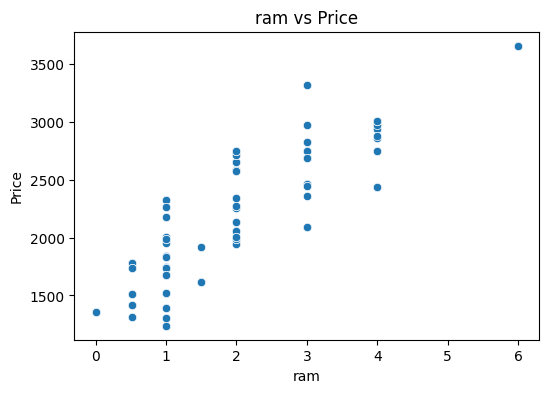

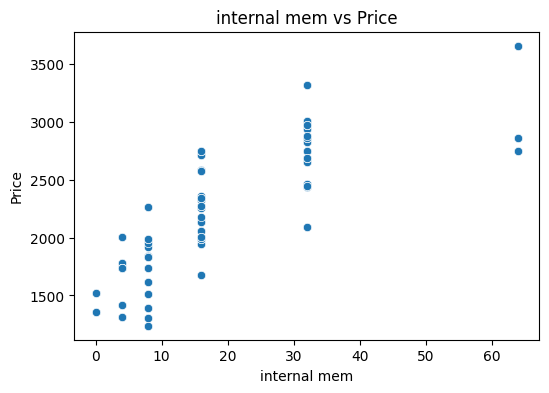

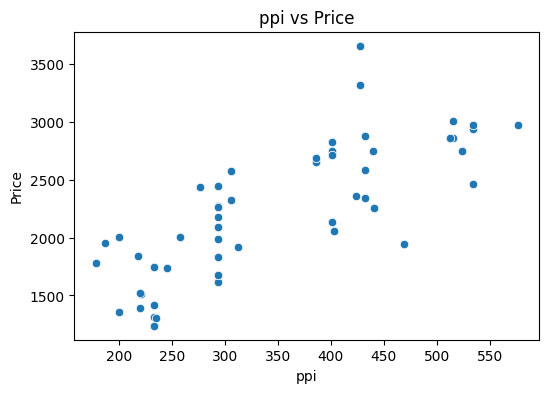

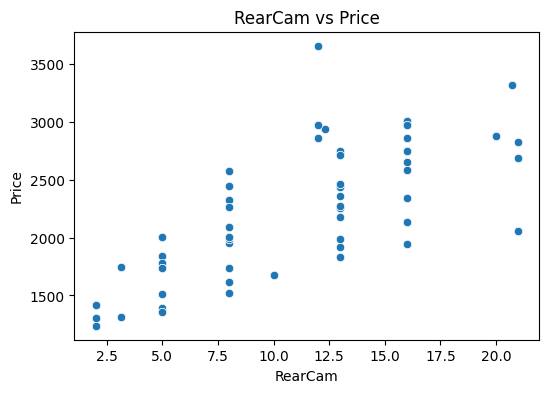


FEATURES SHAPE : (106, 13)
TARGET SHAPE : (106,)

TRAINING DATA SHAPE
(84, 13)

TESTING DATA SHAPE
(22, 13)

MODEL TRAINED SUCCESSFULLY

COEFFICIENTS
         Feature  Coefficient
0     Product_id     0.002432
1           Sale    -0.135000
2         weight     3.884842
3    resoloution  -217.647058
4            ppi     1.237662
5       cpu core    71.883086
6       cpu freq   142.877169
7   internal mem     1.863500
8            ram   124.567757
9        RearCam     2.714617
10     Front_Cam    -5.671849
11       battery     0.137527
12     thickness  -109.003561

INTERCEPT
2023.1414419808123

MODEL PERFORMANCE
R2 SCORE : 0.8120618926316355
MAE : 178.4624672882309
MSE : 50964.23469768803

ACTUAL VS PREDICTED VALUES
     Actual Price  Predicted Price
131          1357      1389.632343
10           2438      2888.309766
4            1749      1551.928359
103          2343      2407.143238
124          2880      3074.666299
74           2571      2173.738090
31           2977      3233.9

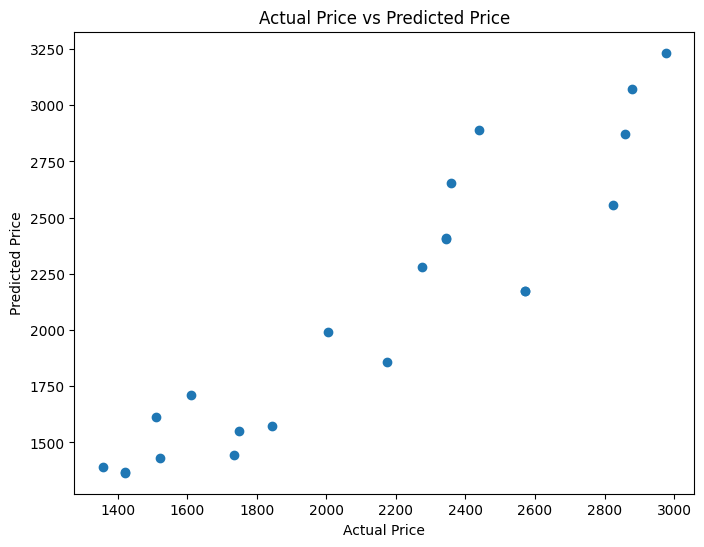

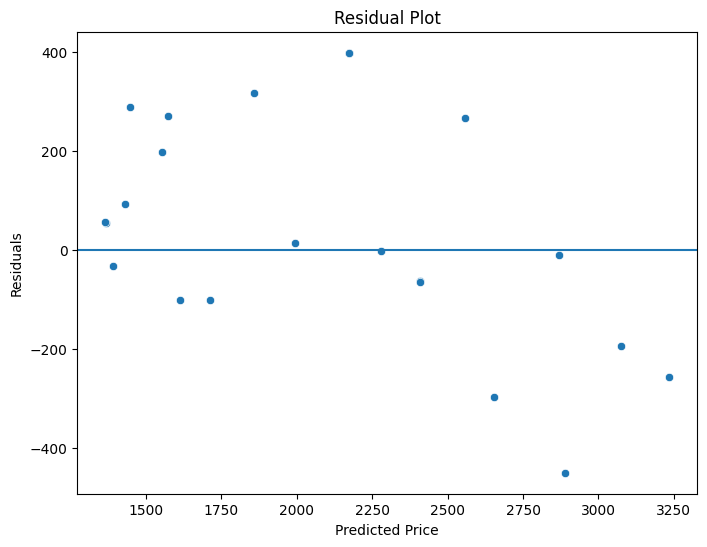


FINAL MODEL EVALUATION

1. The dataset was explored by checking shape, columns,
   data types, missing values, and summary statistics.

2. Duplicate records and missing values were handled
   during data cleaning.

3. Outliers were removed using the IQR method.

4. Correlation analysis identified the features most
   strongly related to mobile price.

5. Scatter plots were generated for the top 4 features
   correlated with Price.

6. The dataset was split into 80% training data and
   20% testing data.

7. A Linear Regression model was built and trained.

8. The slope (coefficient) values show how much the
   Price changes when a feature increases by one unit.

9. Positive coefficients indicate a positive impact
   on Price, while negative coefficients indicate a
   negative impact.

10. The intercept represents the baseline predicted
    Price when all feature values are zero.

11. R² Score indicates how well the model explains
    the variation in mobile prices.

12. MAE measures t

In [1]:
# ============================================================
# ASSIGNMENT 6 : LINEAR REGRESSION
# Mobile Price Prediction
# ============================================================

# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ==========================
# Load Dataset
# ==========================
url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/mobile_price.csv"

df = pd.read_csv(url)

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

# ============================================================
# 1. DATA EXPLORATION
# ============================================================

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

print("\nDUPLICATE ROWS")
print(df.duplicated().sum())

print("\nSTATISTICAL SUMMARY")
print(df.describe())

# ============================================================
# 2. DATA CLEANING
# ============================================================

df = df.drop_duplicates()

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

print("\nDATASET SHAPE AFTER CLEANING")
print(df.shape)

# ============================================================
# 3. OUTLIER HANDLING USING IQR
# ============================================================

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)

    df = df[
        (df[col] >= lower_limit) &
        (df[col] <= upper_limit)
    ]

print("\nDATASET SHAPE AFTER OUTLIER REMOVAL")
print(df.shape)

# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================

column_names = [col.lower() for col in df.columns]

if "front camera" in column_names and "rear camera" in column_names:

    front_col = df.columns[column_names.index("front camera")]
    rear_col = df.columns[column_names.index("rear camera")]

    df["Total_Camera"] = df[front_col] + df[rear_col]

    print("\nNEW FEATURE CREATED : Total_Camera")

# ============================================================
# 5. CORRELATION HEATMAP
# ============================================================

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# ============================================================
# 6. IDENTIFY TARGET COLUMN
# ============================================================

price_column = None

for col in df.columns:
    if col.lower() == "price":
        price_column = col
        break

if price_column is None:
    raise ValueError("Price column not found in dataset")

print("\nTARGET COLUMN :", price_column)

# ============================================================
# 7. TOP 4 FEATURES MOST CORRELATED WITH PRICE
# ============================================================

price_corr = corr_matrix[price_column].sort_values(ascending=False)

print("\nCORRELATION WITH PRICE")
print(price_corr)

top_features = price_corr.drop(price_column).head(4)

print("\nTOP 4 FEATURES MOST CORRELATED WITH PRICE")
print(top_features)

# ============================================================
# 8. SCATTER PLOTS
# ============================================================

for feature in top_features.index:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        x=df[feature],
        y=df[price_column]
    )

    plt.title(feature + " vs Price")
    plt.xlabel(feature)
    plt.ylabel("Price")

    plt.show()

# ============================================================
# 9. FEATURE SELECTION
# ============================================================

X = df.drop(price_column, axis=1)
y = df[price_column]

print("\nFEATURES SHAPE :", X.shape)
print("TARGET SHAPE :", y.shape)

# ============================================================
# 10. TRAIN TEST SPLIT (80:20)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTRAINING DATA SHAPE")
print(X_train.shape)

print("\nTESTING DATA SHAPE")
print(X_test.shape)

# ============================================================
# 11. BUILD LINEAR REGRESSION MODEL
# ============================================================

model = LinearRegression()

# ============================================================
# 12. TRAIN MODEL
# ============================================================

model.fit(X_train, y_train)

print("\nMODEL TRAINED SUCCESSFULLY")

# ============================================================
# 13. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 14. COEFFICIENTS (SLOPE)
# ============================================================

coef_df = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": model.coef_
    }
)

print("\nCOEFFICIENTS")
print(coef_df)

# ============================================================
# 15. INTERCEPT
# ============================================================

print("\nINTERCEPT")
print(model.intercept_)

# ============================================================
# 16. MODEL PERFORMANCE METRICS
# ============================================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nMODEL PERFORMANCE")
print("R2 SCORE :", r2)
print("MAE :", mae)
print("MSE :", mse)

# ============================================================
# 17. ACTUAL VS PREDICTED VALUES
# ============================================================

results = pd.DataFrame(
    {
        "Actual Price": y_test,
        "Predicted Price": y_pred
    }
)

print("\nACTUAL VS PREDICTED VALUES")
print(results.head(10))

# ============================================================
# 18. ACTUAL VS PREDICTED PLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual Price vs Predicted Price")

plt.show()

# ============================================================
# 19. RESIDUAL PLOT
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

# ============================================================
# 20. FINAL CONCLUSION
# ============================================================

print("\n" + "="*60)
print("FINAL MODEL EVALUATION")
print("="*60)

print("""
1. The dataset was explored by checking shape, columns,
   data types, missing values, and summary statistics.

2. Duplicate records and missing values were handled
   during data cleaning.

3. Outliers were removed using the IQR method.

4. Correlation analysis identified the features most
   strongly related to mobile price.

5. Scatter plots were generated for the top 4 features
   correlated with Price.

6. The dataset was split into 80% training data and
   20% testing data.

7. A Linear Regression model was built and trained.

8. The slope (coefficient) values show how much the
   Price changes when a feature increases by one unit.

9. Positive coefficients indicate a positive impact
   on Price, while negative coefficients indicate a
   negative impact.

10. The intercept represents the baseline predicted
    Price when all feature values are zero.

11. R² Score indicates how well the model explains
    the variation in mobile prices.

12. MAE measures the average prediction error.

13. MSE measures the squared prediction error and
    penalizes larger errors.

14. If R² is high and MAE/MSE are low, the model
    performs well and predicts mobile prices accurately.

15. Possible improvements include feature scaling,
    advanced feature engineering, Ridge Regression,
    Lasso Regression, and Cross Validation.
""")
